Ecuación de la recta:
y = 5.64x + 49.86

Predicciones:
  3.5 horas → nota estimada: 69.6
  9.0 horas → nota estimada: 100.6

R² (coeficiente de determinación): 0.995


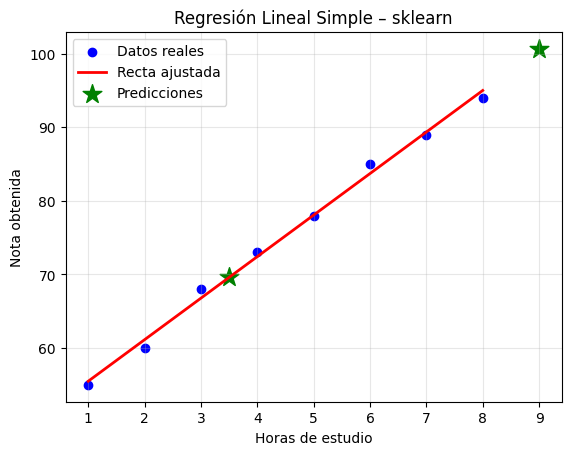

In [1]:
# Ejemplo básico de Regresión Lineal con sklearn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Datos de ejemplo (inventados)
# Horas de estudio vs Nota obtenida
horas_estudio = np.array([1, 2, 3, 4, 5, 6, 7, 8]).reshape(-1, 1)   # X
notas = np.array([55, 60, 68, 73, 78, 85, 89, 94])                  # y

# 2. Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(horas_estudio, notas)

# 3. Obtener los parámetros del modelo
pendiente    = modelo.coef_[0]      # coeficiente (m)
intercepto   = modelo.intercept_    # intercepto (b)
ecuacion = f"y = {pendiente:.2f}x + {intercepto:.2f}"

print("Ecuación de la recta:")
print(ecuacion)

# 4. Predecir valores
horas_pred = np.array([[3.5], [9]]) # queremos predecir para 3.5 y 9 horas
notas_pred = modelo.predict(horas_pred)

print("\nPredicciones:")
for h, n in zip(horas_pred.flatten(), notas_pred):
    print(f"  {h:.1f} horas → nota estimada: {n:.1f}")

# 5. Calidad del ajuste (R²)
r2 = r2_score(notas, modelo.predict(horas_estudio))
print(f"\nR² (coeficiente de determinación): {r2:.3f}")

# 6. Gráfico (opcional pero muy recomendable)
plt.scatter(horas_estudio, notas, color='blue', label='Datos reales')
plt.plot(horas_estudio, modelo.predict(horas_estudio), color='red', linewidth=2, label='Recta ajustada')
plt.scatter(horas_pred, notas_pred, color='green', marker='*', s=200, label='Predicciones')

plt.xlabel('Horas de estudio')
plt.ylabel('Nota obtenida')
plt.title('Regresión Lineal Simple – sklearn')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Saving dataset_delivery.xlsx to dataset_delivery.xlsx
Shape: (20, 5)


,Distancia_km,Trafico,Hora_pico,Pedidos_pendientes,Tiempo_entrega_min
0,6.2,10,1,5,83.2
1,14.3,3,1,1,86.7
2,11.2,7,1,3,91.1
3,9.4,4,0,5,70.9
4,3.2,9,1,4,71.1


Variable dependiente (Y): Tiempo_entrega_min
Variables independientes (X): ['Distancia_km', 'Trafico', 'Hora_pico', 'Pedidos_pendientes']
Intercepto (β0): 8.596025496158042

Coeficientes:
Distancia_km: 4.108685709205082
Trafico: 2.799218208071925
Hora_pico: 7.745921148077569
Pedidos_pendientes: 2.2967456898473344

R²: 0.9767405639702699
MAE: 2.0964690520330955
MSE: 7.155705020012792


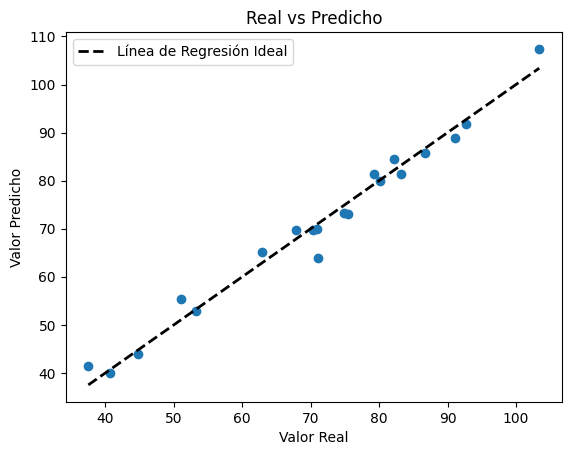

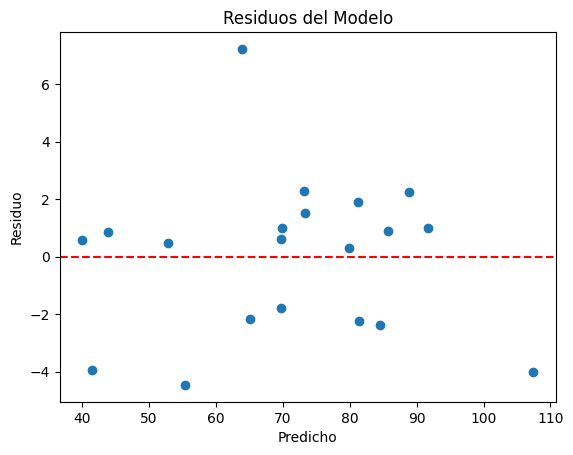


DataFrame con columna de Residuos:


,Distancia_km,Trafico,Hora_pico,Pedidos_pendientes,Tiempo_entrega_min,Residuos
0,6.2,10,1,5,83.2,1.908291
1,14.3,3,1,1,86.7,0.909447
2,11.2,7,1,3,91.1,2.256009
3,9.4,4,0,5,70.9,1.001728
4,3.2,9,1,4,71.1,7.230312


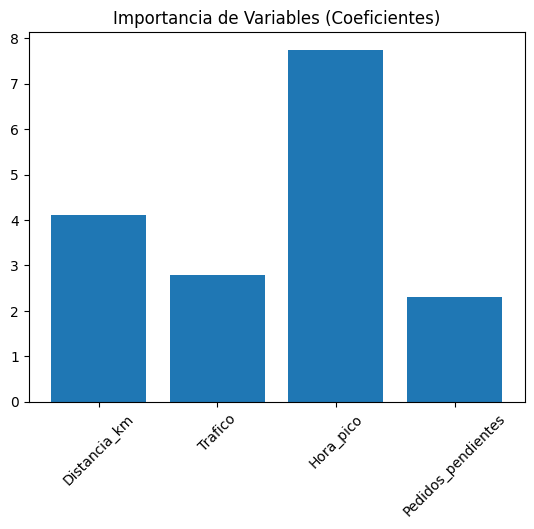

In [1]:
# =========================================
# 1) SUBIR ARCHIVO EXCEL
# =========================================
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd

filename = next(iter(uploaded.keys()))
# Load the Excel file, skipping the first row (header=1 for 0-indexed row 1)
df = pd.read_excel(io.BytesIO(uploaded[filename]), header=1)

# Rename columns for easier access and to remove special characters
# Based on the user's request and common column names from similar datasets
df.columns = ['ID', 'Distancia_km', 'Trafico', 'Hora_pico', 'Pedidos_pendientes', 'Tiempo_entrega_min']

# Drop the 'ID' column as it's not needed for regression
df = df.drop(columns=['ID'])

print("Shape:", df.shape)
display(df.head())

# =========================================
# 2) SELECCIONAR VARIABLES
# =========================================

# The user explicitly stated the variables.
Y_COL = "Tiempo_entrega_min"     # variable dependiente
X_COLS = ["Distancia_km", "Trafico", "Hora_pico", "Pedidos_pendientes"]   # variables independientes

print("Variable dependiente (Y):", Y_COL)
print("Variables independientes (X):", X_COLS)

# Ensure selected columns are numeric, coercing errors to NaN
for col in X_COLS + [Y_COL]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Eliminar valores nulos después de la conversión
data = df[X_COLS + [Y_COL]].dropna()

# =========================================
# 3) DEFINIR X e Y
# =========================================
X = data[X_COLS].values
y = data[Y_COL].values

# =========================================
# 4) ENTRENAR MODELO DE REGRESIÓN LINEAL MÚLTIPLE
# =========================================
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

# =========================================
# 5) RESULTADOS DEL MODELO
# =========================================
import numpy as np

print("Intercepto (β0):", model.intercept_)
print("\nCoeficientes:")

for name, coef in zip(X_COLS, model.coef_):
    print(f"{name}: {coef}")

print("\nR²:", model.score(X, y))
print("MAE:", np.mean(np.abs(y - y_pred)))
print("MSE:", np.mean((y - y_pred)**2))

# =========================================
# 6) GRÁFICO 1: REAL vs PREDICHO
# =========================================
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Línea de Regresión Ideal') # Add ideal regression line
plt.xlabel("Valor Real")
plt.ylabel("Valor Predicho")
plt.title("Real vs Predicho")
plt.legend()
plt.show()

# =========================================
# 7) GRÁFICO 2: RESIDUOS
# =========================================
residuals = y - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--') # Changed to red dashed line for clarity
plt.xlabel("Predicho")
plt.ylabel("Residuo")
plt.title("Residuos del Modelo")
plt.show()

# Añadir los residuos como una nueva columna al DataFrame 'data'
data['Residuos'] = residuals
print("\nDataFrame con columna de Residuos:")
display(data.head())

# =========================================
# 8) GRÁFICO 3: IMPORTANCIA DE VARIABLES
# =========================================
plt.figure()
plt.bar(X_COLS, model.coef_)
plt.xticks(rotation=45)
plt.title("Importancia de Variables (Coeficientes)")
plt.show()

### Explicación Didáctica del Script de Regresión Lineal

 Como Analistas de Datos queremos descubrir qué factores influyen en el tiempo de entrega de un pedido. En este caso no es necesario `estandarizar/normalizar` los datos porque cada columna esta dentro de un rango específico.

### 1. **Cargar el archivo Excel**

Primero, necesitamos nuestros datos. El código te pide que subas un archivo Excel. Una vez que lo subes, lo lee y lo guarda en algo que llamamos `DataFrame` de Pandas, que es como una tabla inteligente de Excel en Python. Hemos ajustado la lectura para que tome los encabezados correctos de tus datos.

### 2. **Seleccionar las variables**

Aquí le decimos al programa qué columnas de nuestra tabla son importantes:

*   **`Y_COL` (Variable Dependiente):** Es lo que queremos predecir o explicar. En este caso, es el **'Tiempo_entrega_min'**. Piensa en ello como el 'resultado' que nos interesa.
*   **`X_COLS` (Variables Independientes):** Son los factores que creemos que influyen en el tiempo de entrega. Aquí son la **'Distancia_km'**, el **'Trafico'**, la **'Hora_pico'** y los **'Pedidos_pendientes'**. Estos son nuestros 'factores' o 'causas'.

También nos aseguramos de que todos los números sean, de verdad, números, y eliminamos cualquier fila que tenga datos faltantes para no confundir al modelo.

### 3. **Preparar X e Y**

Una vez que tenemos nuestras variables seleccionadas y limpias, las organizamos para que el modelo las entienda. `X` contiene todos nuestros factores (distancia, tráfico, etc.), e `y` contiene los tiempos de entrega reales.

### 4. **Entrenar el Modelo de Regresión Lineal Múltiple**

Le pasamos a `sklearn` (una librería de aprendizaje automático) nuestros datos `X` e `y`. El modelo `LinearRegression()` lo que hace es encontrar la 'fórmula' matemática que mejor explica cómo los factores `X` se relacionan con el tiempo de entrega `y`. Es como si encontrara una receta para predecir el tiempo de entrega basándose en esos factores.

### 5. **Resultados del Modelo**

Después de que el modelo 'aprende' la relación, nos da sus 'descubrimientos':

*   **`Intercepto (β0)`:** Es el tiempo de entrega base, es decir, el tiempo que se tardaría un pedido si todas las demás variables (distancia, tráfico, etc.) fueran cero. Es el punto de partida de nuestra predicción.
*   **`Coeficientes`:** Son los 'pesos' o la 'importancia' de cada factor. Por ejemplo:
    *   Si 'Distancia_km' tiene un coeficiente de 4.109, significa que por cada kilómetro adicional, el tiempo de entrega aumenta aproximadamente 4.109 minutos.
    *   Si 'Hora_pico' tiene un coeficiente de 7.746, significa que durante la hora pico, el tiempo de entrega aumenta aproximadamente 7.746 minutos extra (comparado con no estar en hora pico), manteniendo los demás factores constantes.

*   **`R²` (Coeficiente de Determinación):** ¡Este es muy importante! Un valor de 0.977 significa que el 97.7% de las variaciones en el tiempo de entrega se pueden explicar por nuestros factores.
*   **`MAE` (Error Absoluto Medio):** En promedio, la predicción de nuestro modelo se equivoca por unos 2.096 minutos. Cuanto más pequeño sea, mejor.
*   **`MSE` (Error Cuadrático Medio):** Similar al MAE, pero penaliza más los errores grandes. También queremos que sea pequeño.

### 6. **Gráfico 1: Real vs Predicho**

Este gráfico compara los tiempos de entrega *reales* con los tiempos que nuestro modelo *predijo*. Los puntos azules son cada uno de tus pedidos. La línea discontinua negra es la línea 'perfecta' (donde lo real es igual a lo predicho). Si tus puntos azules están cerca de esa línea, ¡significa que tu modelo es muy bueno!

### 7. **Gráfico 2: Residuos del Modelo**

Los `Residuos` son la 'diferencia' entre el tiempo de entrega real y el tiempo de entrega predicho por el modelo. Este gráfico muestra estos errores. Lo ideal es que los puntos estén distribuidos al azar alrededor de la línea roja (que representa un error de cero). Si vemos patrones aquí (por ejemplo, que los errores son siempre positivos para predicciones bajas y negativos para predicciones altas), podría indicar que el modelo podría mejorarse.

Se ha añadido una nueva columna a tu tabla llamada `Residuos`, para que puedas ver el error específico de cada pedido en tu dataset. Los residuos explican lo que el modelo NO sabe.

En `la toma de decisiones`: Lo más peligroso no es lo que sabemos, sino lo que no estamos midiendo. Los residuos nos muestran ese “no medido”.

### 8. **Gráfico 3: Importancia de Variables (Coeficientes)**

Este gráfico de barras visualiza los coeficientes de los que hablamos antes. Cuanto más alta sea la barra (sin importar si es positiva o negativa), más 'impacto' tiene esa variable en el tiempo de entrega. Nos ayuda a ver rápidamente qué factores son los más influyentes según nuestro modelo.

╔══════════════════════════════════════════════╗
║   DATASET — Velocidad vs Consumo de Combustible  ║
╠══════════════════════════════════════════════╣
   Velocidad_kmh  Consumo_L100km
0           20.0            8.93
1           35.0            7.14
2           50.0            6.51
3           65.0            6.20
4           80.0            5.78
5           95.0            6.32
6          110.0            6.98
7          125.0            7.47
8          140.0            9.69
9          155.0           11.30
╠══════════════════════════════════════════════╣
       Velocidad_kmh  Consumo_L100km
count         10.000          10.000
mean          87.500           7.632
std           45.415           1.780
min           20.000           5.780
25%           53.750           6.368
50%           87.500           7.060
75%          121.250           8.565
max          155.000          11.300
╚══════════════════════════════════════════════╝

  Grado del polinomio:  2
  β₀ (intercepto):     11.16

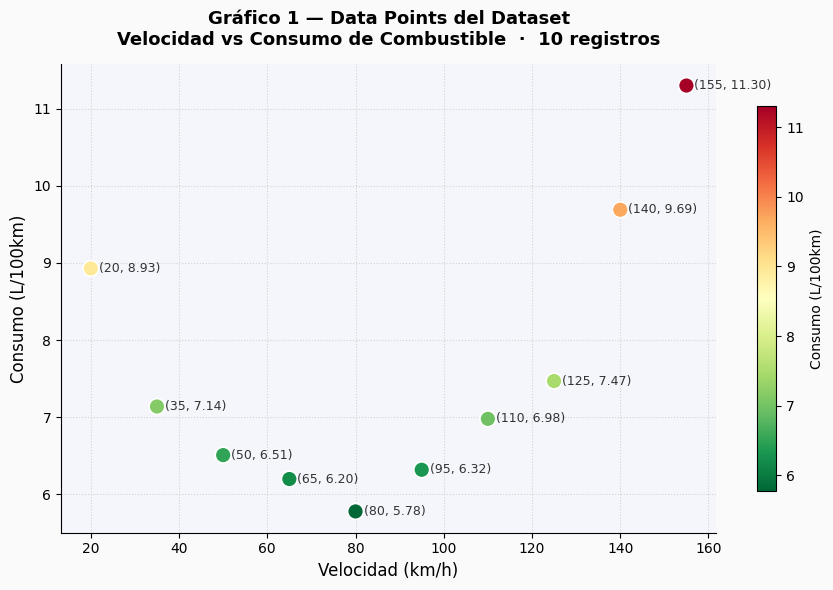


✅  Gráfico 1 guardado: grafico1_datapoints.png


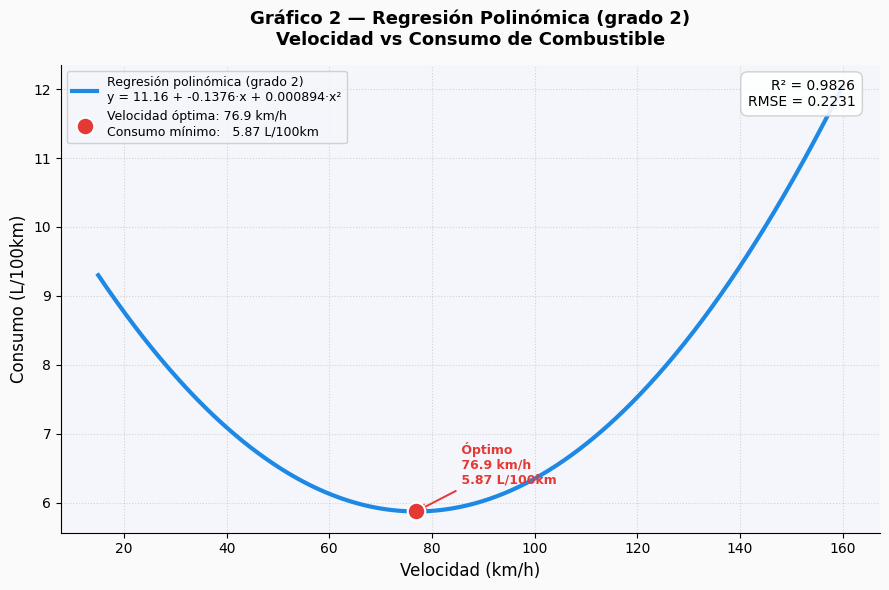

✅  Gráfico 2 guardado: grafico2_regresion_polinomica.png


In [6]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║   REGRESIÓN POLINÓMICA — GOOGLE COLAB                           ║
# ║   10 registros · 2 gráficos limpios · pandas + scikit-learn     ║
# ╚══════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# ══════════════════════════════════════════════════════════════════
# 1. DATASET — 10 registros
#    Contexto: velocidad de un auto (km/h) vs consumo (L/100km)
#    Relación real: curva en U — muy lento o muy rápido = más consumo
# ══════════════════════════════════════════════════════════════════
np.random.seed(7)

velocidad = np.array([20, 35, 50, 65, 80, 95, 110, 125, 140, 155],
                     dtype=float)

# Curva cuadrática real + ruido pequeño
consumo_real = 0.0008 * velocidad**2 - 0.12 * velocidad + 10.5
ruido        = np.random.normal(0, 0.3, len(velocidad))
consumo      = np.round(consumo_real + ruido, 2)

df = pd.DataFrame({
    "Velocidad_kmh":  velocidad,
    "Consumo_L100km": consumo
})

print("╔══════════════════════════════════════════════╗")
print("║   DATASET — Velocidad vs Consumo de Combustible  ║")
print("╠══════════════════════════════════════════════╣")
print(df.to_string(index=True))
print("╠══════════════════════════════════════════════╣")
print(df.describe().round(3).to_string())
print("╚══════════════════════════════════════════════╝")

# ══════════════════════════════════════════════════════════════════
# 2. REGRESIÓN POLINÓMICA (grado 2)
# ══════════════════════════════════════════════════════════════════
GRADO = 2

X = df[["Velocidad_kmh"]].values
y = df["Consumo_L100km"].values

poly    = PolynomialFeatures(degree=GRADO, include_bias=True)
X_poly  = poly.fit_transform(X)

model   = LinearRegression()
model.fit(X_poly, y)

y_pred  = model.predict(X_poly)
r2      = r2_score(y, y_pred)
rmse    = np.sqrt(mean_squared_error(y, y_pred))

# Curva suave para graficar (500 puntos entre min y max)
x_curve = np.linspace(velocidad.min() - 5, velocidad.max() + 5, 500).reshape(-1, 1)
y_curve = model.predict(poly.transform(x_curve))

# Vértice (mínimo consumo) = -b1 / (2·b2)
b0, b1, b2 = model.intercept_, model.coef_[1], model.coef_[2]
x_vertice  = -b1 / (2 * b2)
y_vertice  = model.predict(poly.transform([[x_vertice]]))[0]

# Reporte
print(f"\n  Grado del polinomio:  {GRADO}")
print(f"  β₀ (intercepto):     {b0:.4f}")
print(f"  β₁ (lineal):         {b1:.4f}")
print(f"  β₂ (cuadrático):     {b2:.6f}")
print(f"  R²:                  {r2:.4f}")
print(f"  RMSE:                {rmse:.4f}")
print(f"\n  Ecuación: Consumo = {b0:.3f} + {b1:.4f}·v + {b2:.6f}·v²")
print(f"  Velocidad óptima (mínimo consumo): {x_vertice:.1f} km/h  →  {y_vertice:.2f} L/100km")

# ══════════════════════════════════════════════════════════════════
# ESTILO GLOBAL
# ══════════════════════════════════════════════════════════════════
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.facecolor":  "#FAFAFA",
    "axes.facecolor":    "#F4F6FB",
    "axes.grid":         True,
    "grid.linestyle":    ":",
    "grid.alpha":        0.5,
})

# ══════════════════════════════════════════════════════════════════
# GRÁFICO 1 — SOLO DATA POINTS
# ══════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(9, 6))

sc = ax1.scatter(
    df["Velocidad_kmh"], df["Consumo_L100km"],
    c=df["Consumo_L100km"], cmap="RdYlGn_r",
    s=130, edgecolors="white", linewidths=1.2,
    zorder=4
)

# Etiqueta en cada punto
for i, row in df.iterrows():
    ax1.annotate(
        f"  ({row.Velocidad_kmh:.0f}, {row.Consumo_L100km:.2f})",
        xy=(row.Velocidad_kmh, row.Consumo_L100km),
        fontsize=9, color="#333333",
        va="center"
    )

cbar = plt.colorbar(sc, ax=ax1, shrink=0.82)
cbar.set_label("Consumo (L/100km)", fontsize=10)

ax1.set_xlabel("Velocidad (km/h)", fontsize=12)
ax1.set_ylabel("Consumo (L/100km)", fontsize=12)
ax1.set_title(
    "Gráfico 1 — Data Points del Dataset\n"
    "Velocidad vs Consumo de Combustible  ·  10 registros",
    fontsize=13, fontweight="bold", pad=14
)

plt.tight_layout()
plt.savefig("grafico1_datapoints.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅  Gráfico 1 guardado: grafico1_datapoints.png")

# ══════════════════════════════════════════════════════════════════
# GRÁFICO 2 — SOLO LA CURVA DE REGRESIÓN POLINÓMICA
# ══════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(9, 6))

# Curva polinómica
ax2.plot(
    x_curve, y_curve,
    color="#1E88E5", linewidth=3,
    label=f"Regresión polinómica (grado {GRADO})\n"
          f"y = {b0:.2f} + {b1:.4f}·x + {b2:.6f}·x²",
    zorder=3
)

# Punto de mínimo consumo (vértice)
ax2.scatter(
    [x_vertice], [y_vertice],
    color="#E53935", s=160, zorder=5,
    edgecolors="white", linewidths=1.5,
    label=f"Velocidad óptima: {x_vertice:.1f} km/h\n"
          f"Consumo mínimo:   {y_vertice:.2f} L/100km"
)
ax2.annotate(
    f" Óptimo\n {x_vertice:.1f} km/h\n {y_vertice:.2f} L/100km",
    xy=(x_vertice, y_vertice),
    xytext=(x_vertice + 8, y_vertice + 0.4),
    fontsize=9, color="#E53935", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#E53935", lw=1.4)
)

# Métricas en el gráfico
ax2.text(
    0.97, 0.97,
    f"R² = {r2:.4f}\nRMSE = {rmse:.4f}",
    transform=ax2.transAxes,
    ha="right", va="top", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
              edgecolor="#CCCCCC", alpha=0.9)
)

ax2.set_xlabel("Velocidad (km/h)", fontsize=12)
ax2.set_ylabel("Consumo (L/100km)", fontsize=12)
ax2.set_title(
    f"Gráfico 2 — Regresión Polinómica (grado {GRADO})\n"
    f"Velocidad vs Consumo de Combustible",
    fontsize=13, fontweight="bold", pad=14
)
ax2.legend(fontsize=9, loc="upper left",
           framealpha=0.9, edgecolor="#CCCCCC")

plt.tight_layout()
plt.savefig("grafico2_regresion_polinomica.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Gráfico 2 guardado: grafico2_regresion_polinomica.png")

**Regresión Polinómica**

Este código es un ejemplo didáctico que muestra cómo podemos usar la regresión polinómica para *modelar relaciones no lineales entre variables*. En este caso, estamos viendo cómo la velocidad de un auto afecta su consumo de combustible, que a menudo no es una línea recta.

**1. Preparación del Entorno**
Las primeras líneas importan las librerías necesarias:

numpy: Para operaciones numéricas, especialmente con arrays.
pandas: Para la gestión de datos en DataFrames (tablas).
matplotlib.pyplot: Para crear gráficos.
`sklearn.preprocessing.PolynomialFeatures`: Esta es clave. Es una herramienta que nos permite transformar nuestras variables originales para incluir términos polinómicos (como la velocidad al cuadrado, la velocidad al cubo, etc.).
`sklearn.linear_model.LinearRegression`: Aunque haremos regresión polinómica, el modelo subyacente que se entrena sigue siendo una regresión lineal sobre las nuevas características polinómicas.
sklearn.metrics.r2_score, mean_squared_error: Para evaluar qué tan bien se ajusta nuestro modelo a los datos.

**2. Creación del Dataset**

Aquí creamos un dataset de ejemplo para ilustrar el concepto. No cargamos un archivo, sino que generamos datos de manera controlada:

np.random.seed(7): Esto asegura que si ejecutas el código varias veces, obtendrás exactamente los mismos números aleatorios, haciendo el ejemplo reproducible.
velocidad: Creamos un array de velocidades de autos (en km/h).
consumo_real: Calculamos el consumo de combustible basándonos en una fórmula que tiene un término velocidad**2 (velocidad al cuadrado). Esto simula una relación curva real, donde el consumo es alto a muy baja velocidad, baja a velocidades medias, y vuelve a subir a velocidades muy altas (una forma de 'U').
ruido: Agregamos un poco de ruido aleatorio a consumo_real para que los datos no sean perfectamente curvos, sino más realistas.
df = pd.DataFrame(...): Creamos un DataFrame de Pandas con estas velocidades y consumos. Luego, se imprime este DataFrame para que veamos nuestros datos de ejemplo y algunas estadísticas básicas (df.describe()).

**3. Regresión Polinómica (grado 2)**

Esta es la parte central donde aplicamos la técnica:

GRADO = 2: Decidimos que queremos un polinomio de grado 2. Esto significa que nuestro modelo buscará una relación con términos hasta x² (Velocidad al cuadrado).

X = df[["Velocidad_kmh"]].values y y = df["Consumo_L100km"].values: Separamos nuestras variables: X es la velocidad (variable independiente) e y es el consumo (variable dependiente).

poly = PolynomialFeatures(degree=GRADO, include_bias=True): Inicializamos la herramienta que va a generar las características polinómicas. include_bias=True significa que también creará una columna de unos para el término independiente (el β0).

X_poly = poly.fit_transform(X): Aquí transformamos nuestros datos X. Si X era [velocidad], X_poly ahora contendrá [1, velocidad, velocidad^2]. Es decir, creamos nuevas características que nos permiten modelar una curva con una línea recta en un espacio de mayor dimensión.

model = LinearRegression(): Creamos una instancia del modelo de regresión lineal. Aunque estamos haciendo un modelo polinómico, el modelo que usamos para entrenar es una LinearRegression porque las nuevas características (velocidad y velocidad^2) se tratan de manera lineal.

model.fit(X_poly, y): ¡Entrenamos el modelo! Le pasamos las características transformadas (X_poly) y los valores reales (y) para que encuentre los mejores coeficientes para la ecuación Consumo = β0 + β1 * Velocidad + β2 * Velocidad^2.

y_pred = model.predict(X_poly): Una vez entrenado, el modelo predice los valores de consumo usando las mismas características transformadas.

r2 = r2_score(y, y_pred) y rmse = np.sqrt(mean_squared_error(y, y_pred)): Calculamos métricas de evaluación para saber qué tan bien se ajusta nuestro modelo.

x_curve, y_curve: Creamos muchos puntos entre la velocidad mínima y máxima para poder dibujar una curva suave para la regresión.

x_vertice, y_vertice: Calculamos el punto de la velocidad óptima (donde el consumo es mínimo) usando una fórmula de cálculo para el vértice de una parábola (-b1 / (2*b2)).

Finalmente, se imprime un resumen de los resultados, incluyendo los coeficientes (β0, β1, β2), el R², el RMSE, la ecuación del modelo y la velocidad óptima con su consumo mínimo.

**4. Estilo Global de los Gráficos**

Esta sección configura un estilo visual uniforme para todos los gráficos, mejorando su apariencia (fuente, bordes, color de fondo, cuadrícula).

**5. Gráfico 1 — Solo Data Points**

Este gráfico simplemente muestra los puntos de datos originales (velocidad vs. consumo) como un diagrama de dispersión. Los puntos están coloreados según su consumo para una mejor visualización. También se añade una etiqueta a cada punto con sus coordenadas exactas.

**6. Gráfico 2 — Curva de Regresión Polinómica**

Este es el gráfico más importante. Muestra la curva de regresión polinómica que el modelo ha aprendido. Podemos ver cómo esta curva se ajusta a la forma de 'U' de los datos.
Se marca el punto de la velocidad óptima (el vértice de la parábola) donde el consumo de combustible es mínimo, junto con una anotación para destacarlo.
Las métricas de R² y RMSE también se muestran en el gráfico para tener la información de rendimiento a la vista.
En resumen, este script te guía paso a paso en cómo construir y entender un modelo de regresión polinómica, desde la creación de datos hasta la interpretación de los resultados y su visualización, destacando cómo se puede modelar una relación curva con herramientas de regresión lineal transformando las características.

### **Regresión Polinómica: Explicación Didáctica**

Este código es un ejemplo ilustrativo de cómo podemos usar la *regresión polinómica* para modelar relaciones que no son una línea recta. Imagina que queremos entender cómo la velocidad de un auto afecta su consumo de combustible. A menudo, esta relación no es lineal: un auto consume mucho a muy baja velocidad, menos a velocidades medias, y vuelve a consumir más a velocidades muy altas. ¡Es una curva!

---

#### **1. Preparación del Entorno**

Primero, importamos las herramientas que vamos a necesitar:

*   **`numpy`**: Un "matemático" que nos ayuda con números y arreglos.
*   **`pandas`**: Un "organizador de datos" que crea tablas (`DataFrame`) fáciles de manejar.
*   **`matplotlib.pyplot`**: Un "artista" para dibujar nuestros gráficos.
*   **`sklearn.preprocessing.PolynomialFeatures`**: ¡Esta es la herramienta clave para la regresión polinómica! Es como un "fabricante de nuevas variables" que nos permite crear términos como `velocidad²` o `velocidad³` a partir de nuestra `velocidad` original.
*   **`sklearn.linear_model.LinearRegression`**: Nuestro "motor de regresión". Aunque el resultado es una curva, el *mecanismo* interno sigue siendo una regresión lineal sobre las nuevas variables creadas (como `velocidad` y `velocidad²`).
*   **`sklearn.metrics.r2_score`, `mean_squared_error`**: Nuestros "jueces" para evaluar qué tan bien le fue a nuestro modelo.

---

#### **2. Creación del Dataset (Datos de Ejemplo)**

En lugar de cargar un archivo, creamos nuestros propios datos para tener control total del ejemplo:

*   **`np.random.seed(7)`**: Esto es como una "semilla" mágica. Asegura que cada vez que ejecutes el código, los números aleatorios que se generen sean los mismos, haciendo que el experimento sea reproducible.
*   **`velocidad`**: Un listado de diferentes velocidades a las que medimos el consumo.
*   **`consumo_real`**: Calculamos el consumo ideal usando una fórmula que incluye `velocidad**2`. Esto simula esa curva en forma de 'U' de la vida real (consumo alto en extremos, bajo en el medio).
*   **`ruido`**: Añadimos un poco de "imperfección" aleatoria para que los datos parezcan más reales y no una curva perfecta.
*   **`df = pd.DataFrame(...)`**: Guardamos estos datos en nuestra tabla de `pandas`. Luego, mostramos un resumen (`df.describe()`) para que veas qué contienen.

---

#### **3. Regresión Polinómica (grado 2)**

Aquí es donde aplicamos la técnica para encontrar la curva:

*   **`GRADO = 2`**: Decidimos que queremos una curva que se parezca a una parábola (un polinomio de segundo grado). Esto significa que el modelo considerará la `velocidad` y la `velocidad²`.
*   **`X` y `y`**: Separamos nuestra variable "causa" (`X` = Velocidad) de nuestra variable "efecto" (`y` = Consumo).
*   **`poly = PolynomialFeatures(degree=GRADO, include_bias=True)`**: Inicializamos nuestro "fabricante de nuevas variables". Le decimos que cree variables elevadas al grado 2 y que incluya un término `bias` (el intercepto o punto de inicio).
*   **`X_poly = poly.fit_transform(X)`**: ¡Aquí ocurre la transformación! A partir de nuestra `Velocidad`, esta herramienta crea un nuevo conjunto de datos `X_poly` que incluye una columna para la `Velocidad` y otra para la `Velocidad al cuadrado`. ¡Ahora el modelo tiene más "pistas" para encontrar la curva!
*   **`model = LinearRegression()`**: Creamos nuestro "motor de regresión lineal". Aunque nuestro problema es *polinómico*, al haber transformado los datos, para este motor la relación es *lineal* con las *nuevas variables* (`velocidad` y `velocidad²`).
*   **`model.fit(X_poly, y)`**: ¡El modelo "aprende"! Le damos los datos transformados (`X_poly`) y el `consumo` real (`y`). El modelo calcula los mejores valores para los coeficientes (los `β0`, `β1`, `β2` de la ecuación `Consumo = β0 + β1*V + β2*V²`).
*   **`y_pred = model.predict(X_poly)`**: Una vez que el modelo aprendió, le pedimos que haga sus propias predicciones de consumo usando los mismos datos transformados.
*   **`r2`, `rmse`**: Nuestros "jueces" calculan el **R²** (qué tan bien se ajusta la curva, cerca de 1 es muy bueno) y el **RMSE** (el error promedio, cuanto más pequeño, mejor).
*   **`x_curve`, `y_curve`**: Creamos muchos puntos en un rango amplio de velocidades para poder dibujar una curva suave y bonita.
*   **`x_vertice`, `y_vertice`**: Calculamos cuál es la "velocidad óptima" (donde el consumo es mínimo) usando una fórmula del vértice de una parábola.

Al final de esta sección, se imprime un informe completo con los coeficientes, las métricas de evaluación, la ecuación de la curva y la velocidad óptima.

---

#### **4. Estilo Global de los Gráficos**

Esta sección es como darle una "capa de pintura" a nuestros gráficos. Configura un estilo bonito y uniforme para que se vean profesionales (tipo de letra, colores, cuadrículas, etc.).

---

#### **5. Gráfico 1 — Data Points del Dataset**

Este gráfico simplemente muestra los puntos de datos originales (cada punto es una medida de `Velocidad` y `Consumo`). Los puntos están coloreados según su consumo para que sea fácil ver dónde se consume más o menos. También se añade la etiqueta de cada punto para mayor precisión.

---

#### **6. Gráfico 2 — Curva de Regresión Polinómica**

¡Este es el gráfico estrella! Aquí vemos:

*   La **curva azul** que nuestro modelo encontró. Observa cómo sigue esa forma de 'U' en los datos.
*   Un **punto rojo** que indica la `Velocidad óptima` (la que te da el `Consumo mínimo`). Está claramente etiquetado para que no haya dudas.
*   Las métricas **R²** y **RMSE** mostradas directamente en el gráfico para que tengas toda la información relevante a la vista.

Este script te ha mostrado cómo, con la regresión polinómica, puedes ir más allá de las líneas rectas y modelar relaciones más complejas y realistas en tus datos. ¡Es una herramienta muy potente para entender mejor el mundo!

Por favor sube tu archivo Excel (.xlsx o .xls)


Saving dataset_delivery.xlsx to dataset_delivery (2).xlsx

Archivo cargado: dataset_delivery (2).xlsx

Primeras 5 filas del dataframe original (con nombres corregidos):


,Distancia_km,Trafico,Hora_pico,Pedidos_pendientes,Tiempo_entrega_min
0,6.2,10,1,5,83.2
1,14.3,3,1,1,86.7
2,11.2,7,1,3,91.1
3,9.4,4,0,5,70.9
4,3.2,9,1,4,71.1



Tamaño original: 20 filas × 5 columnas

               LIMPIEZA DE DATOS

Valores nulos por columna después de carga inicial:
Distancia_km          0
Trafico               0
Hora_pico             0
Pedidos_pendientes    0
Tiempo_entrega_min    0
dtype: int64

Valores nulos después de rellenar con mediana:
Distancia_km          0
Trafico               0
Hora_pico             0
Pedidos_pendientes    0
Tiempo_entrega_min    0
dtype: int64

Tamaño después de limpieza básica: 20 filas × 5 columnas

         VARIABLES SELECCIONADAS PARA REGRESIÓN
Variable Y (dependiente): Tiempo_entrega_min
Variables X (independientes): ['Distancia_km', 'Trafico', 'Hora_pico', 'Pedidos_pendientes']

              RESULTADOS DE LA REGRESIÓN
Ecuación:   y = 8.5960 + 4.1087 * Distancia_km + 2.7992 * Trafico + 7.7459 * Hora_pico + 2.2967 * Pedidos_pendientes
R² (coeficiente de determinación): 0.9767 (97.67%)


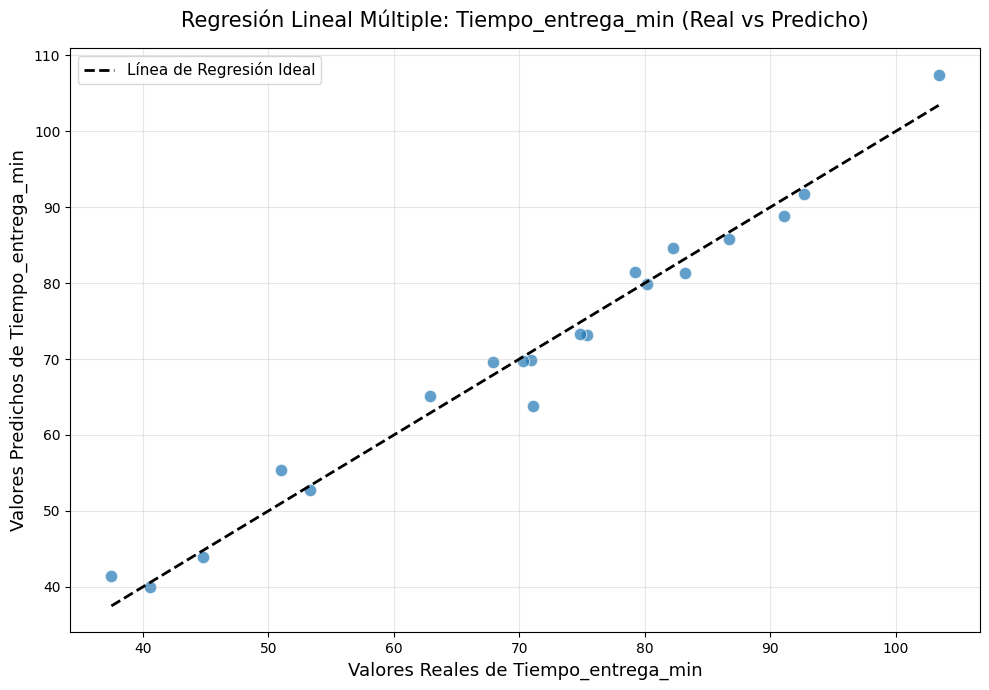

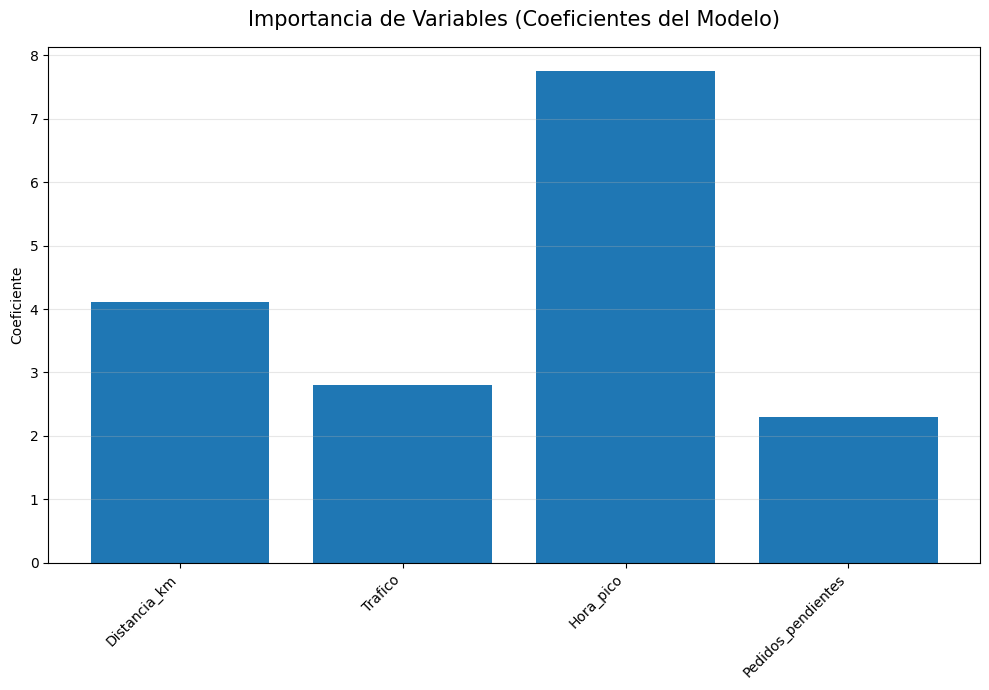

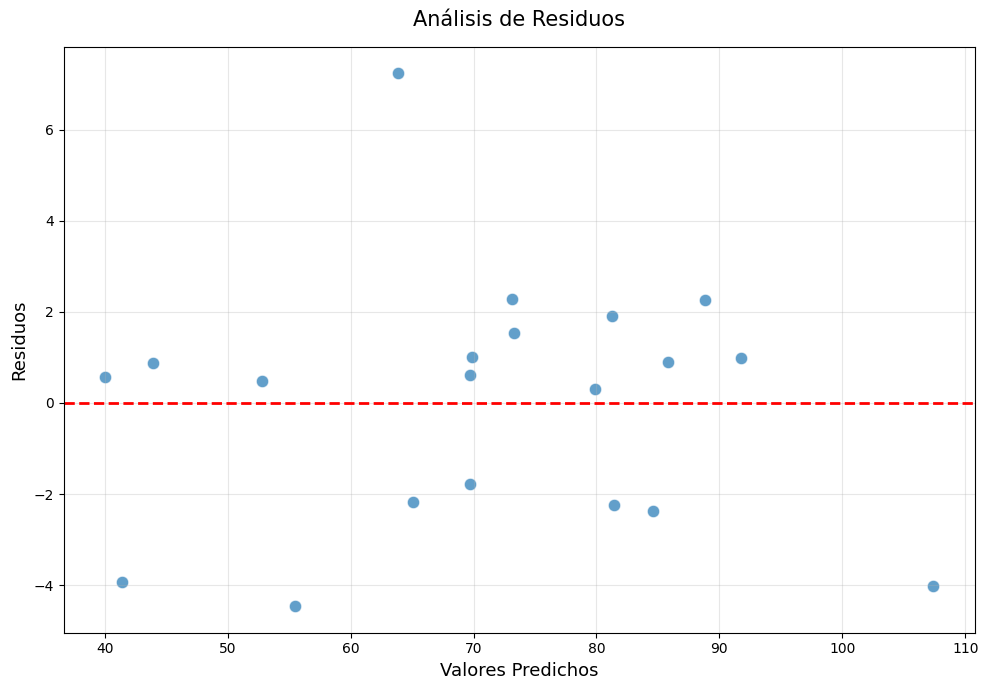


¡Listo! Puedes volver a ejecutar la celda para analizar otro archivo.


In [3]:
# ═══════════════════════════════════════════════════════════════
#  SCRIPT: Carga Excel → Limpieza básica → Regresión Lineal
#  Entorno: Google Colab
# ═══════════════════════════════════════════════════════════════

# 1. Instalamos solo lo que normalmente no viene (por si acaso)
!pip install --quiet openpyxl

# ───────────────────────────────────────────────────────────────
# 2. Importamos las librerías principales
# ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from google.colab import files

# ───────────────────────────────────────────────────────────────
# 3. Subir el archivo Excel
# ───────────────────────────────────────────────────────────────
print("Por favor sube tu archivo Excel (.xlsx o .xls)")
uploaded = files.upload()

# Tomamos el primer (y único) archivo que subiste
filename = list(uploaded.keys())[0]
print(f"\nArchivo cargado: {filename}")

# ───────────────────────────────────────────────────────────────
# 4. Leer el excel (primera hoja por defecto)
# ───────────────────────────────────────────────────────────────
# Assuming the actual headers are in the second row (index 1)
df = pd.read_excel(filename, engine='openpyxl', header=1)

# Rename columns to standardized names as identified in previous successful runs
df.columns = ['ID', 'Distancia_km', 'Trafico', 'Hora_pico', 'Pedidos_pendientes', 'Tiempo_entrega_min']

# Drop the 'ID' column as it's not needed for regression
df = df.drop(columns=['ID'])

print("\nPrimeras 5 filas del dataframe original (con nombres corregidos):")
display(df.head())

print(f"\nTamaño original: {df.shape[0]} filas × {df.shape[1]} columnas")

# ───────────────────────────────────────────────────────────────
# 5. Limpieza automática básica
# ───────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("               LIMPIEZA DE DATOS")
print("="*60)

# 5.1 Eliminar filas completamente vacías
df = df.dropna(how='all')

# 5.2 Eliminar duplicados exactos
df = df.drop_duplicates()

# 5.3 Intentamos convertir columnas numéricas que estén como texto
for col in df.columns:
    # Intentamos convertir a numérico (coerce convierte errores a NaN)
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='ignore')

print("\nValores nulos por columna después de carga inicial:")
print(df.isnull().sum())

# 5.4 Rellenamos nulos numéricos con la mediana (estrategia conservadora)
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("\nValores nulos después de rellenar con mediana:")
print(df.isnull().sum())

print(f"\nTamaño después de limpieza básica: {df.shape[0]} filas × {df.shape[1]} columnas")

# ───────────────────────────────────────────────────────────────
# 6. Seleccionar variables para la regresión
# ───────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("         VARIABLES SELECCIONADAS PARA REGRESIÓN")
print("="*60)

# User specified variables
Y_COL = "Tiempo_entrega_min" # Variable dependiente
X_COLS = ["Distancia_km", "Trafico", "Hora_pico", "Pedidos_pendientes"] # Variables independientes

print("Variable Y (dependiente):", Y_COL)
print("Variables X (independientes):", X_COLS)

# Ensure selected columns are numeric, coercing errors to NaN
for col in X_COLS + [Y_COL]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Eliminar filas con valores nulos después de la conversión para las columnas seleccionadas
data = df[X_COLS + [Y_COL]].dropna()

# ── Elegir variables ─────────────────────────────────────────
# Preparamos datos
X = data[X_COLS].values   # 2D para sklearn
y = data[Y_COL].values

# ───────────────────────────────────────────────────────────
# 7. Regresión lineal
# ───────────────────────────────────────────────────────────
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
pendiente = model.coef_[0]
intercepto = model.intercept_

print("\n" + "="*60)
print("              RESULTADOS DE LA REGRESIÓN")
print("="*60)
# For multiple linear regression, 'pendiente' is not a single value, use coefficients
ecuacion_str = f"y = {intercepto:.4f}"
for i, col_name in enumerate(X_COLS):
    ecuacion_str += f" + {model.coef_[i]:.4f} * {col_name}"
print(f"Ecuación:   {ecuacion_str}")

print(f"R² (coeficiente de determinación): {r2:.4f} ({r2*100:.2f}%)")

# ───────────────────────────────────────────────────────────
# 8. Gráfico bonito con seaborn + línea de regresión
# ───────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))

# For multiple regression, we plot actual vs predicted
sns.scatterplot(x=y, y=y_pred, alpha=0.7, s=80, edgecolor='w')

# Line of ideal prediction (where actual == predicted)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Línea de Regresión Ideal')

plt.xlabel(f'Valores Reales de {Y_COL}', fontsize=13)
plt.ylabel(f'Valores Predichos de {Y_COL}', fontsize=13)
plt.title(f'Regresión Lineal Múltiple: {Y_COL} (Real vs Predicho)', fontsize=15, pad=15)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

# Display Coefficients as Importance of Variables (similar to previous cell)
plt.figure(figsize=(10, 7))
plt.bar(X_COLS, model.coef_)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Coeficiente')
plt.title('Importancia de Variables (Coeficientes del Modelo)', fontsize=15, pad=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plotting residuals
residuals = y - y_pred
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7, s=80, edgecolor='w')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Valores Predichos', fontsize=13)
plt.ylabel('Residuos', fontsize=13)
plt.title('Análisis de Residuos', fontsize=15, pad=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n¡Listo! Puedes volver a ejecutar la celda para analizar otro archivo.")